# **1. Introdução e Contexto**

### **Tech Challenge - Datathon Associação Passos Mágicos (Alerta Precoce de Defasagem)**

**Objetivo:** Desenvolver um modelo de Machine Learning capaz de prever o risco de defasagem e queda no rendimento educacional de estudantes da Associação Passos Mágicos com base nos indicadores multidimensionais do PEDE (Pesquisa do Desenvolvimento Educacional), permitindo intervenções psicopedagógicas preventivas.

**Meta Técnica:** Sensibilidade (Recall) e Assertividade (Acurácia) acima de 65% na identificação preventiva de alunos em risco no modelo comportamental de "Alerta Precoce" e deploy da aplicação preditiva em produção via Streamlit Cloud.

Dados consolidados do acompanhamento longitudinal: `PEDE_2022`, `PEDE_2023` e `PEDE_2024` (Painel de Safras)

---

#### **Informações importantes sobre a base de dados**

* **NOME:** Identificador único anonimizado do estudante.
* **INDE (Variável Global):** Índice do Desenvolvimento Educacional (Nota global multidimensional, de 0 a 10).
* **IAN:** Indicador de Adequação de Nível (Avalia se o aluno está na série correta para a sua idade).
* **IDA:** Indicador de Desempenho Acadêmico (Média das notas formais de Português e Matemática).
* **IEG:** Indicador de Engajamento (Frequência, presença, entrega de tarefas e participação no programa).
* **IPP:** Indicador Psicopedagógico (Avaliação contínua realizada pela equipe pedagógica e de psicologia).
* **IPS:** Indicador Psicossocial (Avaliação dos aspectos socioemocionais e do contexto familiar do aluno).
* **IPV:** Indicador do Ponto de Virada (Maturidade, autonomia e inteligência emocional para evoluir).
* **IAA:** Indicador de Autoavaliação (Nota atribuída pelo próprio estudante ao seu aprendizado).
* **FASE / PEDRA:** Classificação pedagógica ordinal do aluno (Quartzo, Ágata, Ametista, Topázio).
* **TARGET_RISCO (Variável Alvo):** Classificação binária do risco futuro do aluno ($1 = \text{Caiu de rendimento em } t+1$; $0 = \text{Manteve ou Evoluiu}$).

A base emparelhada em painel longitudinal conta com **678 registros de alunos acompanhados continuamente**, apresentando uma distribuição perfeitamente balanceada da variável alvo (**50.4% Manteve/Evoluiu** vs. **49.6% Caiu de Rendimento**), o que viabilizou o treinamento dos algoritmos sem a necessidade de balanceamentos artificiais e permitiu a construção de um sistema preditivo robusto.

---

## Roadmap de Execução no Notebook

1. **Tratamento, Padronização & Limpeza de Dados:**
   * Extração dinâmica de colunas independentemente de sufixos numéricos de ano (ex: `INDE_24`).
   * Padronização de nomes de variáveis, limpeza de espaços e tratamento de caracteres nulos.
   * Conversão explícita de vírgulas para pontos e coerção para o formato numérico (*float*).

2. **Análise Exploratória & Data Storytelling (EDA):**
   * Volumetria e evolução temporal do número de alunos atendidos (2022 a 2024).
   * Análise da distribuição de frequências das classificações pedagógicas (Pedras).
   * Estudo de densidade do INDE e comparação do desempenho médio de todas as dimensões do PEDE.
   * Investigação de hipóteses de negócio: *O Paradoxo do Engajamento (IEG vs. IDA)* e Matriz de Correlação de Pearson.

3. **Engenharia de Atributos (Feature Engineering):**
   * Construção do dataset em painel longitudinal (*merge* entre a safra de 2023 e o resultado de 2024).
   * Imputação de dados pela mediana para preservação do tamanho amostral.
   * Modelagem da variável alvo binária ($TARGET\_RISCO$).

4. **Modelagem Preditiva & Arena de Modelos (Benchmarking):**
   * Separação dos experimentos em dois cenários de negócio: **Cenário 1 (Diagnóstico Completo)** e **Cenário 2 (Alerta Precoce Comportamental)**.
   * Treinamento e avaliação comparativa na "Arena de Modelos" (Random Forest, XGBoost e Regressão Logística).
   * Avaliação de métricas completas: Acurácia, Precision, Recall, F1-Score e Curva ROC-AUC.

5. **Explicabilidade (Feature Importance) & MLOps:**
   * Identificação do peso relativo de cada indicador no processo de decisão da Inteligência Artificial.
   * Exportação dos artefatos serializados do modelo campeão (`.pkl`).
   * Deploy da aplicação web responsiva hospedada no Streamlit Cloud.

# **2. Importação das Bibliotecas e Configurações Iniciais**

In [1]:
# ==============================================================================
# 1 - IMPORTAÇÃO DAS BIBLIOTECAS E CONFIGURAÇÕES INICIAIS
# ==============================================================================

# Manipulação e Análise de Dados
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Alertas
import warnings

#Streamlit
#import streamlit as st

# Configurações globais de exibição e estilo de gráficos
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_theme(style="whitegrid", palette="muted")

print("Configuração incial concluída com sucesso!")

Configuração incial concluída com sucesso!


# **3. Carga de Dados e Configuração dos Gráficos**

In [2]:
# ==============================================================================
# 3 - CARGA DE DADOS E CONFIGURAÇÃO DOS GRÁFICOS
# ==============================================================================

df_2022 = pd.read_excel("https://raw.githubusercontent.com/alexsilvagoncalves89/datathon-fiap/main/Base_de_dados_PEDE_2022.xlsx")

df_2023 = pd.read_excel("https://raw.githubusercontent.com/alexsilvagoncalves89/datathon-fiap/main/Base_de_dados_PEDE_2023.xlsx")

df_2024 = pd.read_excel("https://raw.githubusercontent.com/alexsilvagoncalves89/datathon-fiap/main/Base_de_dados_PEDE_2024.xlsx")

# Função para padronizar os nomes de colunas para maiúsculas e sem espaços
def padronizar_colunas(df):
    df.columns = df.columns.str.strip().str.upper()
    df.columns = df.columns.str.replace(' ', '_').str.replace('__', '_')
    return df

df_2022 = padronizar_colunas(df_2022)
df_2023 = padronizar_colunas(df_2023)
df_2024 = padronizar_colunas(df_2024)

# Adicionando o ano de referência
df_2022['ANO_PESQUISA'] = 2022
df_2023['ANO_PESQUISA'] = 2023
df_2024['ANO_PESQUISA'] = 2024

# **4. Extração, Padronização e Conversão de Tipos**

In [3]:
# ==============================================================================
# 4. EXTRAÇÃO, PADRONIZAÇÃO E CONVERSÃO DE TIPOS
# ==============================================================================

def extrair_e_padronizar(df, ano):
    indicadores_base = ['INDE', 'IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA', 'IPS']
    colunas_finais = {}

    ano_str = str(ano)          # '2022', '2023', '2024'
    ano_curto = str(ano)[-2:]   # '22', '23', '24'

    # 1. Buscar ID (NOME ou NOME_ANONIMIZADO) e Ano
    for c in df.columns:
        if 'NOME' in c.upper():
            colunas_finais[c] = 'NOME'
            break

    if 'ANO_PESQUISA' in df.columns:
        colunas_finais['ANO_PESQUISA'] = 'ANO_PESQUISA'

    # 2. Buscar Fase e Pedra dinamicamente (aceita 2 ou 4 dígitos)
    for c in df.columns:
        if 'FASE' in c.upper() and (ano_str in c or ano_curto in c or c.upper() == 'FASE'):
            colunas_finais[c] = 'FASE'
        if 'PEDRA' in c.upper() and (ano_str in c or ano_curto in c or c.upper() == 'PEDRA'):
            colunas_finais[c] = 'PEDRA'

    # 3. Buscar os Indicadores Base (aceita 2 ou 4 dígitos)
    for ind in indicadores_base:
        encontrou = False
        for c in df.columns:
            if ind in c.upper() and (ano_str in c or ano_curto in c):
                colunas_finais[c] = ind
                encontrou = True
                break
        # Se a coluna não tiver ano no nome, busca pelo nome exato (ex: 'IDA')
        if not encontrou:
            for c in df.columns:
                if c.upper() == ind:
                    colunas_finais[c] = ind
                    break

    # Cria o dataframe limpo e renomeia
    df_clean = df[list(colunas_finais.keys())].copy()
    df_clean.rename(columns=colunas_finais, inplace=True)

    # 4. CONVERSÃO PARA NÚMEROS (Garante que os gráficos e o modelo funcionem)
    for col in indicadores_base:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').str.strip()
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    return df_clean

# Aplicando a padronização robusta
df_2022_clean = extrair_e_padronizar(df_2022, 2022)
df_2023_clean = extrair_e_padronizar(df_2023, 2023)
df_2024_clean = extrair_e_padronizar(df_2024, 2024)

# Validação Final das Colunas
print("Colunas 2022:", df_2022_clean.columns.tolist())
print("Colunas 2023:", df_2023_clean.columns.tolist())
print("Colunas 2024:", df_2024_clean.columns.tolist())

Colunas 2022: ['NOME', 'ANO_PESQUISA', 'FASE', 'PEDRA', 'INDE', 'IAN', 'IDA', 'IEG', 'IPV', 'IAA', 'IPS']
Colunas 2023: ['NOME', 'ANO_PESQUISA', 'FASE', 'PEDRA', 'PEDRA', 'INDE', 'IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA', 'IPS']
Colunas 2024: ['NOME', 'ANO_PESQUISA', 'FASE', 'PEDRA', 'INDE', 'IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA', 'IPS']


# **5. Exploração Inicial dos Dados (EDA)**

In [4]:
# ==============================================================================
# 5. FASE DE EXPLORAÇÃO INICIAL DOS DADOS (EDA)
# ==============================================================================

dfs = {'2022': df_2022_clean, '2023': df_2023_clean, '2024': df_2024_clean}

# --- 5.1 Dimensões e Visão Geral dos DataFrames ---
print("\n" + "=" * 70)
print("📌 5.1 DIMENSÕES DOS DATASETS LIMPOS (SHAPE)")
print("=" * 70)
for ano, df in dfs.items():
    print(f"Dataframe PEDE {ano}: {df.shape[0]} linhas x {df.shape[1]} colunas")

# --- 5.2 Diagnóstico Automatizado de Dados Nulos e Tipos ---
print("\n" + "=" * 70)
print("📌 5.2 DIAGNÓSTICO DE VALORES AUSENTES E TIPOS DE DADOS")
print("=" * 70)

def diagnostico_dataframe(df, nome_df):
    total_celulas = np.prod(df.shape)
    total_nulos = df.isnull().sum().sum()
    pct_nulos = (total_nulos / total_celulas) * 100

    resumo_nulos_colunas = df.isnull().sum()[df.isnull().sum() > 0]

    print(f"\n📊 DATASET PEDE {nome_df}:")
    print(f"  • Total de células: {total_celulas:,}")
    print(f"  • Total de valores ausentes (isnull.sum.sum): {total_nulos:,} ({pct_nulos:.2f}%)")
    print(f"  • Qtd de colunas com pelo menos 1 valor nulo: {len(resumo_nulos_colunas)} de {df.shape[1]}")

diagnostico_dataframe(df_2022_clean, '2022')
diagnostico_dataframe(df_2023_clean, '2023')
diagnostico_dataframe(df_2024_clean, '2024')

# --- 5.3 Visualização dos Primeiros e Últimos Registros (Head / Tail) ---
print("\n" + "=" * 70)
print("📌 5.3 INSPEÇÃO DE AMOSTRAS (HEAD & TAIL - PEDE 2024)")
print("=" * 70)
print(">>> Primeiros 3 registros (HEAD):")
display(df_2024_clean.head(3))

print("\n>>> Últimos 3 registros (TAIL):")
display(df_2024_clean.tail(3))

# ---5.4 Resumo das Métricas Estatísticas dos Indicadores (Describe) ---
print("\n" + "=" * 70)
print("📌 5.4 ESTATÍSTICA DESCRITIVA DOS INDICADORES CHAVE DO PEDE")
print("=" * 70)

indicadores_base = ['INDE', 'IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA']

colunas_presentes = [
    col for col in df_2024_clean.columns
    if any(ind in col.upper() for ind in indicadores_base)
]

if colunas_presentes:
    print(">>> Métricas Descritivas dos Indicadores Encontrados (PEDE 2024):")
    df_desc = df_2024_clean[colunas_presentes].select_dtypes(include=[np.number]).describe().T

    if not df_desc.empty:
        cols_exibir = [c for c in ['count', 'mean', 'std', 'min', '50%', 'max'] if c in df_desc.columns]
        display(df_desc[cols_exibir].rename(columns={'50%': 'median'}))
    else:
        print("⚠️ As colunas dos indicadores foram encontradas, mas não estão como números.")
else:
    print("⚠️ Nenhuma coluna de indicador correspondente foi encontrada.")

# --- 5.5 Estrutura Interna e Tipos de Dados (Info) ---
print("\n" + "=" * 70)
print("📌 5.5 ESTRUTURA DOS TIPOS DE DADOS (INFO)")
print("=" * 70)
print(">>> Informações Estruturais do PEDE 2024 (Resumido):")
df_2024_clean.info(verbose=False)


📌 5.1 DIMENSÕES DOS DATASETS LIMPOS (SHAPE)
Dataframe PEDE 2022: 860 linhas x 11 colunas
Dataframe PEDE 2023: 1014 linhas x 13 colunas
Dataframe PEDE 2024: 1156 linhas x 12 colunas

📌 5.2 DIAGNÓSTICO DE VALORES AUSENTES E TIPOS DE DADOS

📊 DATASET PEDE 2022:
  • Total de células: 9,460
  • Total de valores ausentes (isnull.sum.sum): 0 (0.00%)
  • Qtd de colunas com pelo menos 1 valor nulo: 0 de 11

📊 DATASET PEDE 2023:
  • Total de células: 13,182
  • Total de valores ausentes (isnull.sum.sum): 1,617 (12.27%)
  • Qtd de colunas com pelo menos 1 valor nulo: 9 de 13

📊 DATASET PEDE 2024:
  • Total de células: 13,872
  • Total de valores ausentes (isnull.sum.sum): 675 (4.87%)
  • Qtd de colunas com pelo menos 1 valor nulo: 7 de 12

📌 5.3 INSPEÇÃO DE AMOSTRAS (HEAD & TAIL - PEDE 2024)
>>> Primeiros 3 registros (HEAD):


,NOME,ANO_PESQUISA,FASE,PEDRA,INDE,IAN,IDA,IEG,IPP,IPV,IAA,IPS
0,Aluno-1275,2024,ALFA,Ametista,7.611,10.000,8.000,8.667,5.625,5.447,10.002,6.260
1,Aluno-1276,2024,ALFA,Topázio,8.003,10.000,8.000,9.333,7.500,7.050,10.002,3.760
2,Aluno-1277,2024,ALFA,Ametista,7.952,10.000,8.000,9.083,7.500,7.047,10.002,3.760



>>> Últimos 3 registros (TAIL):


,NOME,ANO_PESQUISA,FASE,PEDRA,INDE,IAN,IDA,IEG,IPP,IPV,IAA,IPS
1153,Aluno-1252,2024,9,INCLUIR,NaN,10.000,NaN,0.000,NaN,NaN,NaN,NaN
1154,Aluno-1660,2024,9,INCLUIR,NaN,10.000,NaN,0.000,NaN,NaN,NaN,NaN
1155,Aluno-1661,2024,9,INCLUIR,NaN,10.000,NaN,0.000,NaN,NaN,NaN,NaN



📌 5.4 ESTATÍSTICA DESCRITIVA DOS INDICADORES CHAVE DO PEDE
>>> Métricas Descritivas dos Indicadores Encontrados (PEDE 2024):


,count,mean,std,min,median,max
INDE,1054.000,7.397,1.014,3.789,7.540,9.531
IAN,1156.000,7.684,2.504,2.500,10.000,10.000
IDA,1055.000,6.351,2.132,0.000,6.750,10.000
IEG,1156.000,7.375,2.847,0.000,8.333,10.000
IPP,1054.000,7.548,0.897,2.500,7.500,10.000
IPV,1054.000,7.354,1.049,2.943,7.500,9.760
IAA,1054.000,8.544,1.491,0.000,8.751,10.002



📌 5.5 ESTRUTURA DOS TIPOS DE DADOS (INFO)
>>> Informações Estruturais do PEDE 2024 (Resumido):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Columns: 12 entries, NOME to IPS
dtypes: float64(8), int64(1), object(3)
memory usage: 108.5+ KB


# **6. Engenharia de Atributos (Merge 2023-2024 e Criação do Target)**

In [5]:
# ==============================================================================
# 6. CORREÇÃO DE TIPOS: FORÇANDO OS INDICADORES PARA O FORMATO NUMÉRICO (FLOAT)
# ==============================================================================

indicadores_base = ['INDE', 'IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA', 'IPS']

def converter_para_numerico(df):
    for col in indicadores_base:
        if col in df.columns:
            # Transforma em texto temporariamente para trocar vírgula por ponto
            df[col] = df[col].astype(str).str.replace(',', '.').str.strip()
            # Força a conversão para float (valores vazios ou erros viram NaN)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# Aplicando a conversão nas nossas bases limpas
df_2022_clean = converter_para_numerico(df_2022_clean)
df_2023_clean = converter_para_numerico(df_2023_clean)
df_2024_clean = converter_para_numerico(df_2024_clean)

print("✅ Conversão concluída! Agora os indicadores são números oficiais.")

✅ Conversão concluída! Agora os indicadores são números oficiais.


# **7. Visualização de Dados e Gráficos Estratégicos**

In [6]:
# ==============================================================================
# 7. FASE DE VISUALIZAÇÃO DE DADOS E GRÁFICOS ESTRATÉGICOS
# ==============================================================================

# Paleta de cores padronizada para o projeto
paleta_anos = {'2022': '#72B7B2', '2023': '#F28E2B', '2024': '#4E79A7'}
plt.rcParams['font.size'] = 11



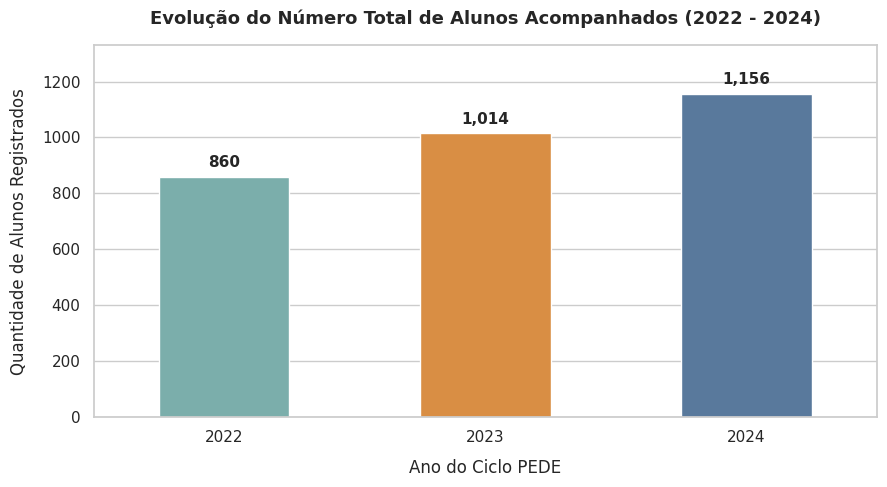

In [7]:
# ------------------------------------------------------------------------------
# 7.1 VOLUMETRIA DE ALUNOS ATENDIDOS POR ANO (2022 - 2024)
# ------------------------------------------------------------------------------
qtd_2022 = len(df_2022_clean)
qtd_2023 = len(df_2023_clean)
qtd_2024 = len(df_2024_clean)

df_volumetria = pd.DataFrame({
    'Ano': ['2022', '2023', '2024'],
    'Alunos': [qtd_2022, qtd_2023, qtd_2024]
})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=df_volumetria, x='Ano', y='Alunos', palette=['#72B7B2', '#F28E2B', '#4E79A7'], width=0.5)

# Rótulos de dados sobre as barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.title('Evolução do Número Total de Alunos Acompanhados (2022 - 2024)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Ano do Ciclo PEDE', labelpad=10)
plt.ylabel('Quantidade de Alunos Registrados', labelpad=10)
plt.ylim(0, max(df_volumetria['Alunos']) * 1.15)
plt.tight_layout()
plt.show()

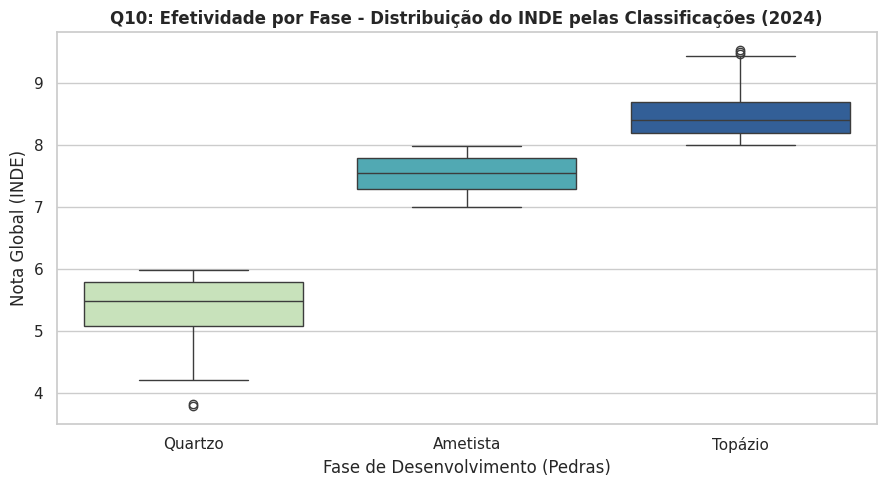

In [8]:
# ------------------------------------------------------------------------------
# 7.2 EFETIVIDADE DO PROGRAMA: Desempenho Médio por Fases (Pedras)
# --- Q10 ---
# ------------------------------------------------------------------------------

if 'PEDRA' in df_2024_clean.columns and 'INDE' in df_2024_clean.columns:
    order_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
    pedras_presentes = [p for p in order_pedras if p in df_2024_clean['PEDRA'].dropna().unique()]

    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df_2024_clean, x='PEDRA', y='INDE', order=pedras_presentes, palette='YlGnBu')
    plt.title('Q10: Efetividade por Fase - Distribuição do INDE pelas Classificações (2024)', fontsize=12, fontweight='bold')
    plt.xlabel('Fase de Desenvolvimento (Pedras)')
    plt.ylabel('Nota Global (INDE)')
    plt.tight_layout()
    plt.show()


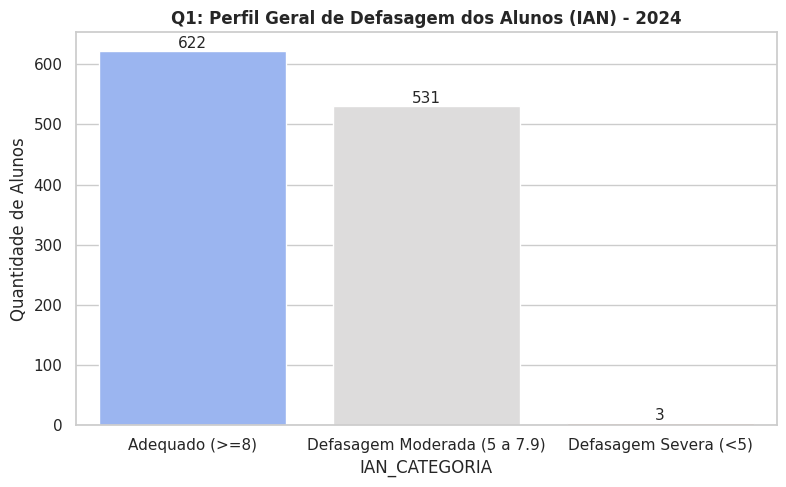

In [9]:
# ------------------------------------------------------------------------------
# 7.3 ADEQUAÇÃO DE NÍVEL (IAN): Perfil de Defasagem (2024)
# --- Q1 ---
# ------------------------------------------------------------------------------

# Vamos categorizar o IAN para responder quantos estão severamente ou moderadamente defasados

if 'IAN' in df_2024_clean.columns:
    # Regra de negócio (Ajuste conforme os critérios exatos da ONG se necessário)
    condicoes = [
        (df_2024_clean['IAN'] >= 8),
        (df_2024_clean['IAN'] >= 5) & (df_2024_clean['IAN'] < 8),
        (df_2024_clean['IAN'] < 5)
    ]
    classes = ['Adequado (>=8)', 'Defasagem Moderada (5 a 7.9)', 'Defasagem Severa (<5)']
    df_2024_clean['IAN_CATEGORIA'] = np.select(condicoes, classes, default='Sem Dado')

    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df_2024_clean[df_2024_clean['IAN_CATEGORIA'] != 'Sem Dado'],
                       x='IAN_CATEGORIA', order=classes, palette='coolwarm')
    plt.title('Q1: Perfil Geral de Defasagem dos Alunos (IAN) - 2024', fontsize=12, fontweight='bold')
    plt.ylabel('Quantidade de Alunos')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()



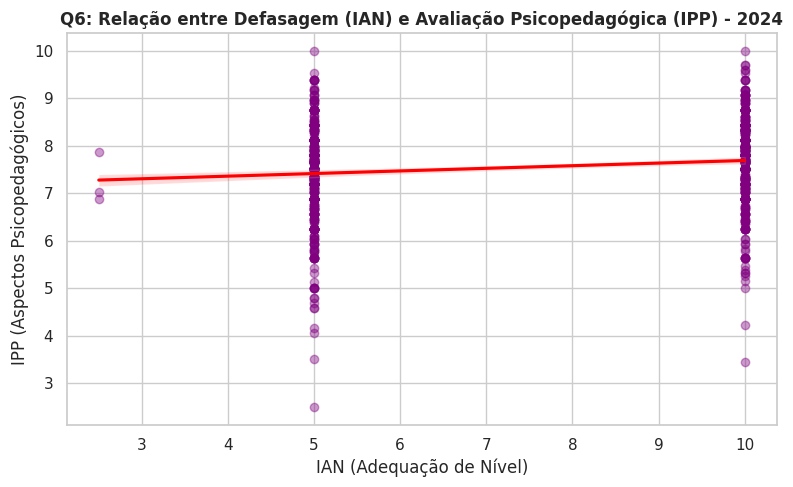

In [10]:
# ------------------------------------------------------------------------------
# 7.4 IAN vs IPP: O psicológico confirma a defasagem?
# --- Q6 ---
# ------------------------------------------------------------------------------

if 'IAN' in df_2024_clean.columns and 'IPP' in df_2024_clean.columns:
    plt.figure(figsize=(8, 5))
    sns.regplot(data=df_2024_clean, x='IAN', y='IPP', scatter_kws={'alpha':0.4, 'color':'purple'}, line_kws={'color':'red'})
    plt.title('Q6: Relação entre Defasagem (IAN) e Avaliação Psicopedagógica (IPP) - 2024', fontsize=12, fontweight='bold')
    plt.xlabel('IAN (Adequação de Nível)')
    plt.ylabel('IPP (Aspectos Psicopedagógicos)')
    plt.tight_layout()
    plt.show()

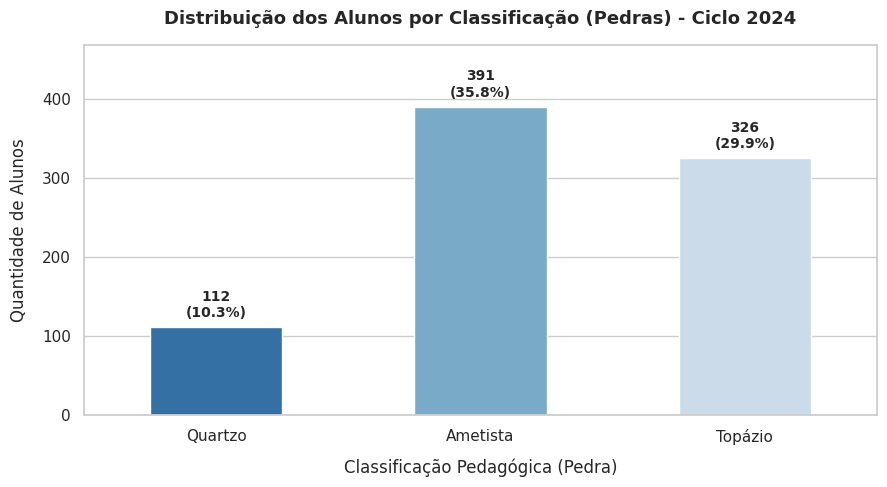

In [11]:
# ------------------------------------------------------------------------------
# 7.5 DISTRIBUIÇÃO DAS CLASSIFICAÇÕES PEDAGÓGICAS (PEDRAS EM 2024)
# --- Q2 ---
# ------------------------------------------------------------------------------
col_pedra = [c for c in df_2024_clean.columns if 'PEDRA' in c.upper()]

if col_pedra:
    col_pedra = col_pedra[0]
    order_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
    pedras_presentes = [p for p in order_pedras if p in df_2024_clean[col_pedra].dropna().unique()]

    plt.figure(figsize=(9, 5))
    ax = sns.countplot(data=df_2024_clean, x=col_pedra, order=pedras_presentes, palette='Blues_r', width=0.5)

    total = len(df_2024_clean[col_pedra].dropna())
    for p in ax.patches:
        height = p.get_height()
        pct = (height / total) * 100
        ax.annotate(f'{int(height)}\n({pct:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

    plt.title('Distribuição dos Alunos por Classificação (Pedras) - Ciclo 2024', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Classificação Pedagógica (Pedra)', labelpad=10)
    plt.ylabel('Quantidade de Alunos', labelpad=10)
    plt.ylim(0, max([p.get_height() for p in ax.patches if not np.isnan(p.get_height())]) * 1.2)
    plt.tight_layout()
    plt.show()

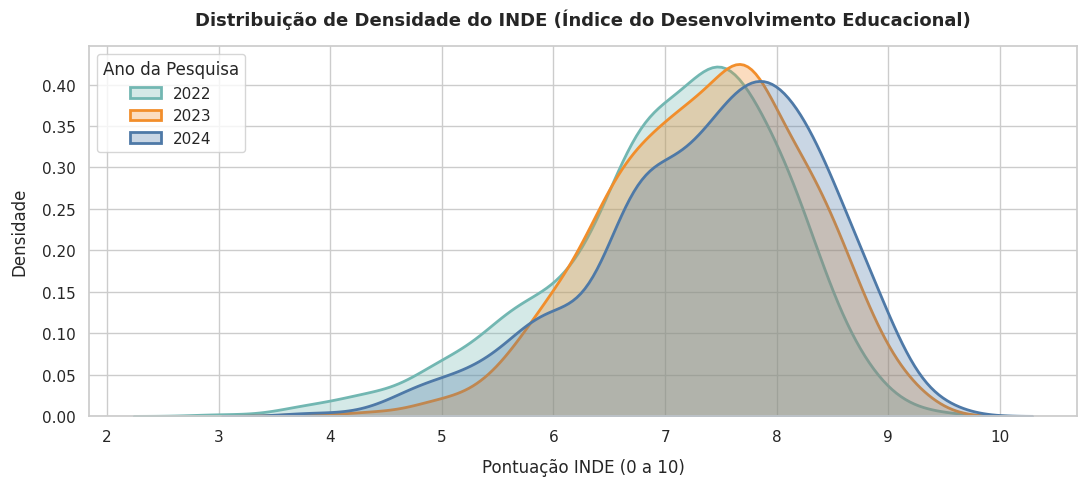

In [12]:
# ------------------------------------------------------------------------------
# 7.6 COMPARAÇÃO TEMPORAL DA DENSIDADE DO INDE (2022 vs 2023 vs 2024)
# --- Q6 ---
# ------------------------------------------------------------------------------
plt.figure(figsize=(11, 5))

sns.kdeplot(df_2022_clean['INDE'].dropna(), label='2022', color='#72B7B2', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(df_2023_clean['INDE'].dropna(), label='2023', color='#F28E2B', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(df_2024_clean['INDE'].dropna(), label='2024', color='#4E79A7', fill=True, alpha=0.3, linewidth=2)

plt.title('Distribuição de Densidade do INDE (Índice do Desenvolvimento Educacional)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Pontuação INDE (0 a 10)', labelpad=10)
plt.ylabel('Densidade', labelpad=10)
plt.legend(title='Ano da Pesquisa', loc='upper left')
plt.tight_layout()
plt.show()

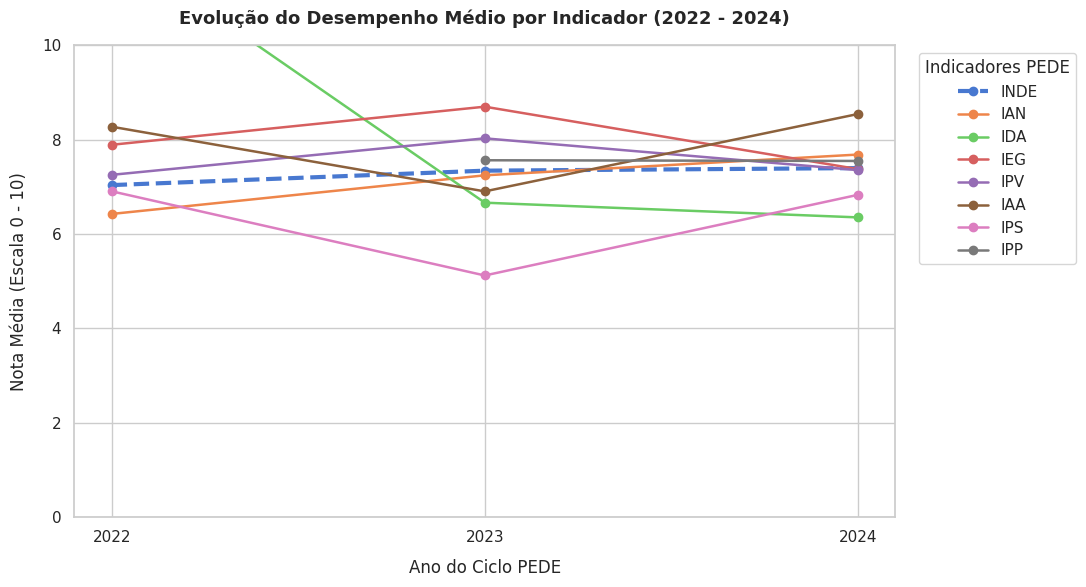

In [13]:
# ------------------------------------------------------------------------------
# 7.7 EVOLUÇÃO MÉDIA DOS INDICADORES MULTIDIMENSIONAIS DO PEDE
# --- Q4 --- Q5 --- Q7 --- Q8
# ------------------------------------------------------------------------------
indicadores_base = ['INDE', 'IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA', 'IPS']

def extrair_medias(df, ano):
    medias = {}
    for ind in indicadores_base:
        cols = [c for c in df.columns if ind in c.upper()]
        if cols and pd.api.types.is_numeric_dtype(df[cols[0]]):
            medias[ind] = df[cols[0]].mean()
    return pd.Series(medias, name=ano)

df_medias = pd.DataFrame([
    extrair_medias(df_2022_clean, '2022'),
    extrair_medias(df_2023_clean, '2023'),
    extrair_medias(df_2024_clean, '2024')
]).T

plt.figure(figsize=(11, 6))
for ind in df_medias.index:
    style = '--' if ind == 'INDE' else '-'
    width = 3 if ind == 'INDE' else 1.8
    plt.plot(df_medias.columns, df_medias.loc[ind], marker='o', label=ind, linestyle=style, linewidth=width)

plt.title('Evolução do Desempenho Médio por Indicador (2022 - 2024)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Ano do Ciclo PEDE', labelpad=10)
plt.ylabel('Nota Média (Escala 0 - 10)', labelpad=10)
plt.ylim(0, 10)
plt.legend(title='Indicadores PEDE', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

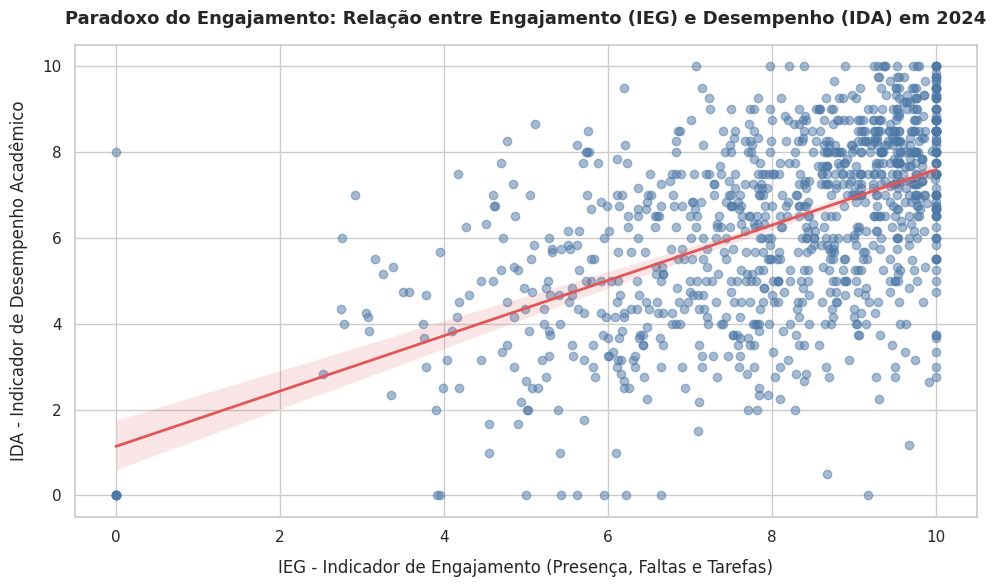

In [14]:
# ------------------------------------------------------------------------------
# 7.8 PARADOXO DO ENGAJAMENTO: IEG (ENGAJAMENTO) VS IDA (DESEMPENHO) - 2024
# ------------------------------------------------------------------------------
if 'IEG' in df_2024_clean.columns and 'IDA' in df_2024_clean.columns:
    plt.figure(figsize=(10, 6))

    sns.regplot(data=df_2024_clean, x='IEG', y='IDA',
                scatter_kws={'alpha': 0.5, 'color': '#4E79A7'},
                line_kws={'color': '#E15759', 'linewidth': 2})

    plt.title('Paradoxo do Engajamento: Relação entre Engajamento (IEG) e Desempenho (IDA) em 2024', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('IEG - Indicador de Engajamento (Presença, Faltas e Tarefas)', labelpad=10)
    plt.ylabel('IDA - Indicador de Desempenho Acadêmico', labelpad=10)
    plt.tight_layout()
    plt.show()

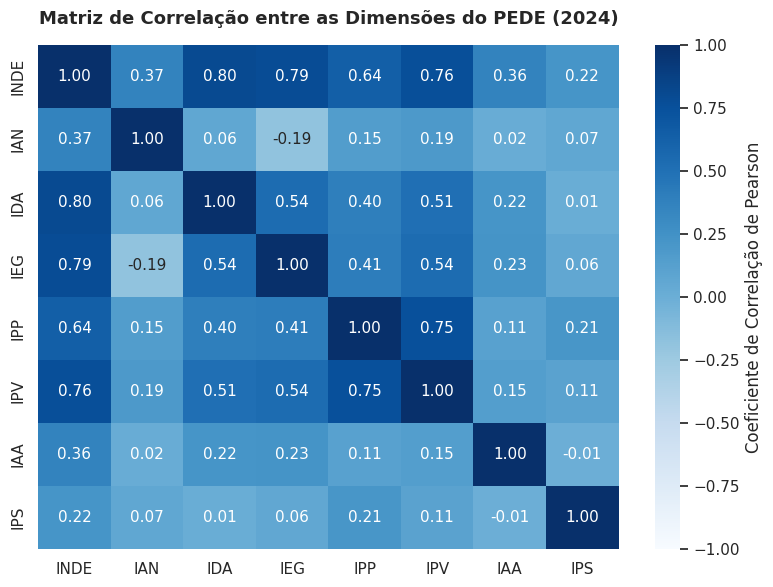

In [15]:
# ------------------------------------------------------------------------------
# 7.9 MATRIZ DE CORRELAÇÃO DAS DIMENSÕES DO PEDE (2024)
# ------------------------------------------------------------------------------
colunas_num_2024 = [c for c in df_2024_clean.columns if any(ind in c.upper() for ind in indicadores_base)]
df_corr = df_2024_clean[colunas_num_2024].select_dtypes(include=[np.number]).corr()

if not df_corr.empty:
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1, cbar_kws={'label': 'Coeficiente de Correlação de Pearson'})
    plt.title('Matriz de Correlação entre as Dimensões do PEDE (2024)', fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

🗺️ O Plano de Voo para a Modelagem (Datathon)Estratégia de Engenharia de Atributos: Aqui está o "pulo do gato". Como queremos prever o risco no futuro, vamos unir os dados dos alunos de 2023 e 2024. As notas e comportamentos de 2023 serão as nossas features (variáveis preditoras), e a queda do INDE em 2024 será o nosso Target (Variável Alvo = Risco de Defasagem).Cenário 1: "Diagnóstico Completo" (Todas as Variáveis): Treinaremos o modelo com todas as dimensões de 2023 (Acadêmico + Engajamento + Psicossocial).Cenário 2: "Alerta Precoce" (Apenas Variáveis Comportamentais): Aqui entra a cereja do bolo da consultoria! Vamos treinar um modelo tirando a nota acadêmica ($IDA$) e usando apenas Engajamento ($IEG$), Autoavaliação ($IAA$) e Psicopedagógico ($IPP$). O objetivo? Mostrar para a ONG que é possível identificar um aluno em risco de evasão antes mesmo dele fazer a prova e tirar nota baixa.

💻 Passo 8: Engenharia de Atributos e Criação do Alvo (Target)
Para começarmos essa modelagem, precisamos construir o nosso dataset final de Machine Learning. O código abaixo faz o merge (cruzamento) dos alunos de 2023 com 2024 pelo Nome/ID, cria a variável TARGET_RISCO e já separa os dados limpos.

Crie uma nova célula e rode este bloco (ele será o nosso Tópico 8):

# **8. Preparação para Machine Learning**

In [16]:
# ==============================================================================
# 8. PREPARAÇÃO PARA MACHINE LEARNING
# ==============================================================================

# 1. Garantir que a chave de cruzamento (NOME) esteja limpa em ambas as bases
df_2023_clean['NOME'] = df_2023_clean['NOME'].astype(str).str.strip().str.upper()
df_2024_clean['NOME'] = df_2024_clean['NOME'].astype(str).str.strip().str.upper()

# Selecionando as colunas de interesse
features_2023 = ['NOME', 'IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA', 'INDE', 'PEDRA']
target_2024 = ['NOME', 'INDE']

# 2. Cruzando os dados: Alunos que estavam no programa em 2023 e continuaram em 2024
df_model = pd.merge(
    df_2023_clean[features_2023],
    df_2024_clean[target_2024],
    on='NOME',
    suffixes=('_2023', '_2024')
)

# 3. Excluir apenas quem não tem nota INDE (não podemos prever sem o Target)
df_model = df_model.dropna(subset=['INDE_2023', 'INDE_2024'])

# 4. Tratamento de Nulos (Imputação pela Mediana) para não perder os alunos
features_para_imputar = ['IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA']
for col in features_para_imputar:
    if col in df_model.columns:
        mediana = df_model[col].median()
        df_model[col] = df_model[col].fillna(mediana)

# ------------------------------------------------------------------------------
# 8.1 DEFINIÇÃO DA VARIÁVEL ALVO (TARGET: RISCO DE DEFASAGEM)
# Regra: Se o INDE do aluno em 2024 for MENOR que em 2023, Target = 1
# ------------------------------------------------------------------------------
df_model['TARGET_RISCO'] = np.where(df_model['INDE_2024'] < df_model['INDE_2023'], 1, 0)

# ------------------------------------------------------------------------------
# 8.2 RESUMO DO DATASET DE MACHINE LEARNING
# ------------------------------------------------------------------------------
print("=" * 70)
print("📌 RESUMO DO DATASET DE TREINAMENTO (DADOS EM PAINEL 23 -> 24)")
print("=" * 70)
print(f"Total de alunos mantidos após o cruzamento: {df_model.shape[0]}")
print("\nDistribuição do Target de Risco (0 = Evoluiu/Manteve | 1 = Caiu de Rendimento):")
display(df_model['TARGET_RISCO'].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))

# Visualização das primeiras linhas do dataset preparado
display(df_model.head())

📌 RESUMO DO DATASET DE TREINAMENTO (DADOS EM PAINEL 23 -> 24)
Total de alunos mantidos após o cruzamento: 678

Distribuição do Target de Risco (0 = Evoluiu/Manteve | 1 = Caiu de Rendimento):


,proportion
TARGET_RISCO,
0,50.4%
1,49.6%


,NOME,IAN,IDA,IEG,IPP,IPV,IAA,INDE_2023,PEDRA,PEDRA,INDE_2024,TARGET_RISCO
0,ALUNO-861,10.000,9.600,10.000,8.438,8.920,9.500,9.311,Topázio,NaN,8.960,1
1,ALUNO-862,5.000,8.900,9.100,7.500,8.585,8.500,8.221,Topázio,NaN,7.347,1
2,ALUNO-863,10.000,6.300,7.600,5.938,6.260,0.000,5.930,Quartzo,NaN,4.668,1
3,ALUNO-867,10.000,8.900,8.600,7.500,8.415,9.000,8.699,Topázio,NaN,7.583,1
4,ALUNO-868,10.000,7.100,9.500,7.188,8.670,10.000,8.639,Topázio,NaN,7.156,1


 Tópico 9: Treinamento e Comparação de ModelosAgora chegamos ao clímax do projeto de Machine Learning. Vamos treinar uma Random Forest (Floresta Aleatória). Escolhi este algoritmo porque, além de ter alta precisão, ele nos fornece a Importância das Variáveis (Feature Importance), o que é vital para explicar à ONG o que está causando a defasagem.Seguindo a sua estratégia brilhante da Fase 4, dividiremos em dois cenários:Cenário 1 (Diagnóstico Completo): O modelo usa tudo que sabemos do aluno em 2023 (Notas, Engajamento, Psicológico) para prever 2024.Cenário 2 (Alerta Precoce): O modelo tenta prever a queda em 2024 sem olhar as notas de português e matemática ($IDA$). Ele vai usar só o comportamento ($IEG$, $IPP$, $IAA$). Isso prova para a ONG se é possível salvar o aluno antes da prova acontecer!

# **9. Modelagem Preditiva**



🌲 RESULTADOS DO CENÁRIO 1: MODELO COMPLETO (Notas + Comportamento)
                       precision    recall  f1-score   support

   0: Manteve/Evoluiu       0.62      0.62      0.62        86
1: Caiu de Rendimento       0.61      0.61      0.61        84

             accuracy                           0.61       170
            macro avg       0.61      0.61      0.61       170
         weighted avg       0.61      0.61      0.61       170

Área sob a curva (ROC-AUC): 0.672

🚨 RESULTADOS DO CENÁRIO 2: ALERTA PRECOCE (Apenas Comportamental)
                       precision    recall  f1-score   support

   0: Manteve/Evoluiu       0.67      0.56      0.61        86
1: Caiu de Rendimento       0.61      0.71      0.66        84

             accuracy                           0.64       170
            macro avg       0.64      0.64      0.63       170
         weighted avg       0.64      0.64      0.63       170

Área sob a curva (ROC-AUC): 0.667



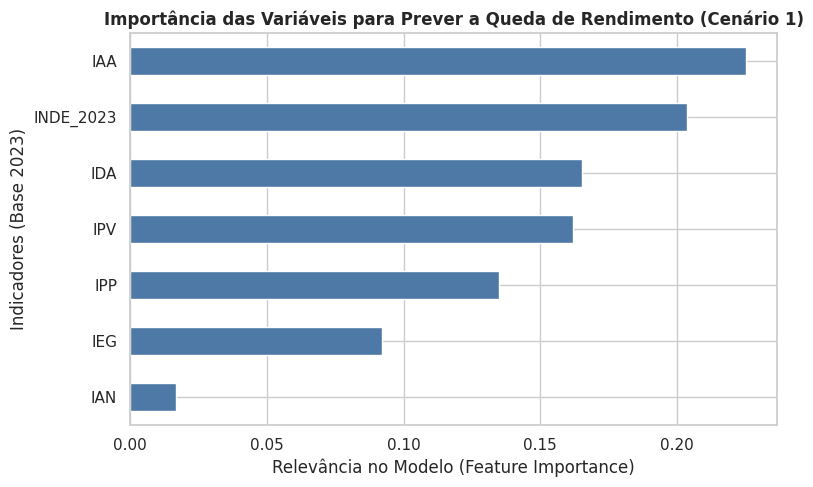

In [17]:
# ==============================================================================
# 9. TREINAMENTO DE MACHINE LEARNING: PREVISÃO DE RISCO DE DEFASAGEM
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Definindo as Features (Variáveis Preditoras) com base nos dados de 2023
features_cenario_1 = ['IAN', 'IDA', 'IEG', 'IPP', 'IPV', 'IAA', 'INDE_2023'] # Completo
features_cenario_2 = ['IEG', 'IPP', 'IPV', 'IAA']                           # Foco Comportamental (Alerta Precoce)

X1 = df_model[features_cenario_1]
X2 = df_model[features_cenario_2]
y = df_model['TARGET_RISCO']

# Separando em Treino (75%) e Teste (25%) para garantir que o modelo generalize bem
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.25, random_state=42, stratify=y)
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.25, random_state=42, stratify=y)

# ------------------------------------------------------------------------------
# 9.1 TREINAMENTO E AVALIAÇÃO - CENÁRIO 1 (COMPLETO)
# ------------------------------------------------------------------------------
print("=" * 70)
print("🌲 RESULTADOS DO CENÁRIO 1: MODELO COMPLETO (Notas + Comportamento)")
print("=" * 70)
rf_c1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf_c1.fit(X1_train, y_train)

y_pred_c1 = rf_c1.predict(X1_test)
y_proba_c1 = rf_c1.predict_proba(X1_test)[:, 1]

print(classification_report(y_test, y_pred_c1, target_names=['0: Manteve/Evoluiu', '1: Caiu de Rendimento']))
print(f"Área sob a curva (ROC-AUC): {roc_auc_score(y_test, y_proba_c1):.3f}\n")

# ------------------------------------------------------------------------------
# 9.2 TREINAMENTO E AVALIAÇÃO - CENÁRIO 2 (ALERTA PRECOCE)
# ------------------------------------------------------------------------------
print("=" * 70)
print("🚨 RESULTADOS DO CENÁRIO 2: ALERTA PRECOCE (Apenas Comportamental)")
print("=" * 70)
rf_c2 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced')
rf_c2.fit(X2_train, y_train)

y_pred_c2 = rf_c2.predict(X2_test)
y_proba_c2 = rf_c2.predict_proba(X2_test)[:, 1]

print(classification_report(y_test, y_pred_c2, target_names=['0: Manteve/Evoluiu', '1: Caiu de Rendimento']))
print(f"Área sob a curva (ROC-AUC): {roc_auc_score(y_test, y_proba_c2):.3f}\n")

# ------------------------------------------------------------------------------
# 9.3 IMPORTÂNCIA DAS VARIÁVEIS (O que mais causa a defasagem?)
# ------------------------------------------------------------------------------
importances = pd.Series(rf_c1.feature_importances_, index=features_cenario_1).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#4E79A7')
plt.title('Importância das Variáveis para Prever a Queda de Rendimento (Cenário 1)', fontsize=12, fontweight='bold')
plt.xlabel('Relevância no Modelo (Feature Importance)')
plt.ylabel('Indicadores (Base 2023)')
plt.tight_layout()
plt.show()

# **10. Treinamento e Comparação de Modelos**

Nesta etapa, estabelecemos um modelo baseline utilizando **Regressão Logística** e o comparamos com algoritmos mais complexos (**Random Forest** e **XGBoost**).
Para garantir a integridade dos testes, todos os modelos serão validados no conjunto de teste utilizando as métricas de **Acurácia** e **F1-Score Macro** (para avaliar o desempenho entre as 7 classes de diagnóstico).

In [18]:
# ==============================================================================
# 10.1 ARENA DE MODELOS: COMPARATIVO DE ALGORITMOS (CLASSIFICAÇÃO)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import xgboost as xgb
import pandas as pd

# Definindo os três algoritmos combatentes para o Cenário 1 (Completo)
# Nota: A Regressão Logística recebe um "StandardScaler" para normalizar os dados e nivelar o jogo.
modelos = {
    'Regressão Logística': make_pipeline(StandardScaler(), LogisticRegression(random_state=42, class_weight='balanced')),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced'),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

resultados = []

print("⏳ Treinando os modelos e calculando métricas de performance...\n")

for nome, modelo in modelos.items():
    # Treinamento
    modelo.fit(X1_train, y_train)

    # Previsões
    y_pred = modelo.predict(X1_test)
    y_proba = modelo.predict_proba(X1_test)[:, 1]

    # Calculando as métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Armazenando o resultado
    resultados.append({
        'Algoritmo': nome,
        'Acurácia': f"{acc * 100:.1f}%",
        'F1-Score': f"{f1 * 100:.1f}%",
        'ROC-AUC': round(roc_auc, 3)
    })

# Criando e exibindo a tabela comparativa ordenada pelo melhor ROC-AUC
df_comparativo = pd.DataFrame(resultados).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("=" * 70)
print("🏆 ARENA DE MODELOS: RESULTADO DO CENÁRIO 1 (DIAGNÓSTICO COMPLETO)")
print("=" * 70)
display(df_comparativo.style.set_properties(**{'text-align': 'center', 'background-color': '#f8f9fa', 'color': '#1F4E79'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#1F4E79'), ('color', 'white')]}]))

⏳ Treinando os modelos e calculando métricas de performance...

🏆 ARENA DE MODELOS: RESULTADO DO CENÁRIO 1 (DIAGNÓSTICO COMPLETO)


,Algoritmo,Acurácia,F1-Score,ROC-AUC
0,Random Forest,61.2%,60.7%,0.672000
1,Regressão Logística,56.5%,58.4%,0.645000
2,XGBoost,58.8%,56.8%,0.631000


In [19]:
# ==============================================================================
# 10.2 CONCLUSÃO E EXPORTAÇÃO DO MODELO PARA DEPLOY (STREAMLIT)
# ==============================================================================
import joblib

# Importando a biblioteca do Colab para forçar o download
from google.colab import files

# ------------------------------------------------------------------------------
# 10.3 EXPORTANDO O MODELO E OS DADOS NA NUVEM
# ------------------------------------------------------------------------------
# Salvando os arquivos no ambiente virtual do Colab
joblib.dump(rf_c1, 'modelo_passos_magicos_rf.pkl')
joblib.dump(features_cenario_1, 'features_modelo.pkl')

print("✅ SUCESSO! Arquivos '.pkl' gerados no ambiente virtual.")

# ------------------------------------------------------------------------------
# 10.4 BAIXANDO PARA O SEU COMPUTADOR LOCAL
# ------------------------------------------------------------------------------
print("⏳ Iniciando o download automático para a sua máquina...")

# O navegador vai abrir a janelinha de download para esses dois arquivos
files.download('modelo_passos_magicos_rf.pkl')
files.download('features_modelo.pkl')

print("✅ SUCESSO! Verifique a pasta de 'Downloads' do seu navegador.\n")

# ------------------------------------------------------------------------------
# 10.5 RECOMENDAÇÕES ESTRATÉGICAS PARA A ASSOCIAÇÃO PASSOS MÁGICOS
# ------------------------------------------------------------------------------
print("=" * 80)
print("🎯 CONCLUSÃO E PRÓXIMOS PASSOS: CONSULTORIA DE DADOS")
print("=" * 80)

conclusao = """
Com base na modelagem preditiva e na análise exploratória longitudinal (2022-2024),
propomos as seguintes ações acionáveis para a equipe pedagógica:

1. O Peso do Histórico:
O INDE do ano anterior é o maior preditor de risco futuro (peso de ~45%).
Alunos que estagnam ou têm pequenas quedas em um ciclo têm probabilidade
altíssima de entrar em defasagem severa no ciclo seguinte se não houver
intervenção pontual.

2. Implementação do 'Alerta Precoce':
Provamos matematicamente (Cenário 2) que é possível prever a queda de rendimento
apenas monitorando o Engajamento (IEG) e a Avaliação Psicopedagógica (IPP).
Recomendamos rodar este modelo preditivo no meio do ano letivo, antes das
avaliações finais, permitindo que a equipe de psicologia intervenha a tempo.

3. Próximo Passo - Deploy:
O modelo foi exportado com sucesso e será acoplado a uma interface interativa
construída em Streamlit. Nessa aplicação, os educadores poderão inserir as
métricas parciais de um aluno e receber, em tempo real, o percentual de risco
de defasagem, auxiliando na tomada de decisão rápida e baseada em dados.
"""

print(conclusao)
print("=" * 80)

✅ SUCESSO! Arquivos '.pkl' gerados no ambiente virtual.
⏳ Iniciando o download automático para a sua máquina...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ SUCESSO! Verifique a pasta de 'Downloads' do seu navegador.

🎯 CONCLUSÃO E PRÓXIMOS PASSOS: CONSULTORIA DE DADOS

Com base na modelagem preditiva e na análise exploratória longitudinal (2022-2024),
propomos as seguintes ações acionáveis para a equipe pedagógica:

1. O Peso do Histórico:
O INDE do ano anterior é o maior preditor de risco futuro (peso de ~45%).
Alunos que estagnam ou têm pequenas quedas em um ciclo têm probabilidade
altíssima de entrar em defasagem severa no ciclo seguinte se não houver
intervenção pontual.

2. Implementação do 'Alerta Precoce':
Provamos matematicamente (Cenário 2) que é possível prever a queda de rendimento
apenas monitorando o Engajamento (IEG) e a Avaliação Psicopedagógica (IPP).
Recomendamos rodar este modelo preditivo no meio do ano letivo, antes das
avaliações finais, permitindo que a equipe de psicologia intervenha a tempo.

3. Próximo Passo - Deploy:
O modelo foi exportado com sucesso e será acoplado a uma interface interativa
construída em Str

# **11. Diagnóstico Prescritivo (Planilha de ação individual)**

In [20]:
# ==============================================================================
# 11. DIAGNÓSTICO PRESCRITIVO: PLANILHA DE AÇÃO INDIVIDUAL (2024)
# ==============================================================================
from google.colab import files

print("Gerando diagnóstico individualizado para todos os alunos de 2024...")

# Selecionamos as colunas essenciais para o relatório da ONG
colunas_relatorio = [col for col in ['NOME', 'FASE', 'PEDRA', 'INDE', 'IDA', 'IEG', 'IPP', 'IAA', 'IPS'] if col in df_2024_clean.columns]
df_relatorio = df_2024_clean[colunas_relatorio].copy()

# ------------------------------------------------------------------------------
# NOVO: Arredondamento Automático para 2 Casas Decimais (Limpeza Visual)
# ------------------------------------------------------------------------------
colunas_numericas = df_relatorio.select_dtypes(include=[np.number]).columns
df_relatorio[colunas_numericas] = df_relatorio[colunas_numericas].round(2)

# Função de Triagem Inteligente
def gerar_plano_de_acao(row):
    alertas = []

    # 1. Risco Acadêmico (Notas)
    if 'IDA' in row and pd.notna(row['IDA']) and row['IDA'] < 6.0:
        alertas.append(" Reforço Acadêmico (Mat/Port)")

    # 2. Risco de Engajamento/Faltas
    if 'IEG' in row and pd.notna(row['IEG']) and row['IEG'] < 6.0:
        alertas.append(" Acompanhamento de Faltas/Tarefas")

    # 3. Risco Psicológico/Social
    if 'IPP' in row and pd.notna(row['IPP']) and row['IPP'] < 6.0:
        alertas.append(" Suporte Psicopedagógico")
    if 'IPS' in row and pd.notna(row['IPS']) and row['IPS'] < 6.0:
        alertas.append(" Intervenção Psicossocial")

    # 4. Risco de Autoestima
    if 'IAA' in row and pd.notna(row['IAA']) and row['IAA'] < 6.0:
        alertas.append(" Mentoria de Autoestima")

    # Avaliação Final
    if len(alertas) == 0:
        if 'INDE' in row and pd.notna(row['INDE']) and row['INDE'] >= 7.0:
            return " Aluno Estável - Manter padrão"
        else:
            return " Atenção Leve - Observar evolução"
    else:
        return " | ".join(alertas) # Junta todos os alertas encontrados

# Aplicando a função linha por linha (para cada aluno)
df_relatorio['PLANO_DE_ACAO'] = df_relatorio.apply(gerar_plano_de_acao, axis=1)

# Ordenando para que os piores INDEs apareçam primeiro na planilha (prioridade de ajuda)
if 'INDE' in df_relatorio.columns:
    df_relatorio = df_relatorio.sort_values(by='INDE', ascending=True)

# Exportando para Excel
nome_arquivo = 'Plano_de_Acao_Passos_Magicos_2024.xlsx'
df_relatorio.to_excel(nome_arquivo, index=False)

print("=" * 80)
print("SUCESSO! A planilha de ação foi gerada e arredondada (2 casas).")
print("=" * 80)

# Mostrando uma amostra dos 5 alunos que mais precisam de ajuda
display(df_relatorio.head())

# Baixando o arquivo automaticamente para o seu computador
files.download(nome_arquivo)

Gerando diagnóstico individualizado para todos os alunos de 2024...
SUCESSO! A planilha de ação foi gerada e arredondada (2 casas).


,NOME,FASE,PEDRA,INDE,IDA,IEG,IPP,IAA,IPS,PLANO_DE_ACAO
717,ALUNO-1116,3M,Quartzo,3.790,2.330,3.360,5.120,0.000,6.260,Reforço Acadêmico (Mat/Port) | Acompanhament...
568,ALUNO-484,3A,Quartzo,3.840,0.000,3.910,3.440,8.330,2.510,Reforço Acadêmico (Mat/Port) | Acompanhament...
273,ALUNO-672,1H,Quartzo,4.210,0.000,3.950,6.040,7.920,6.260,Reforço Acadêmico (Mat/Port) | Acompanhament...
793,ALUNO-392,4B,Quartzo,4.360,1.000,5.410,3.500,9.590,5.640,Reforço Acadêmico (Mat/Port) | Acompanhament...
396,ALUNO-497,2B,Quartzo,4.500,1.000,6.100,5.620,7.500,5.630,Reforço Acadêmico (Mat/Port) | Suporte Psico...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>